In [ ]:
# downloading the california housing dataset directly through a defined function

from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))
housing = load_housing_data()

/tmp/ipykernel_11636/2941276561.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


In [ ]:
# inspecting first 10 rows of the data
print(housing.head(10))

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   
5    -122.25     37.85                52.0        919.0           213.0   
6    -122.25     37.84                52.0       2535.0           489.0   
7    -122.25     37.84                52.0       3104.0           687.0   
8    -122.26     37.84                42.0       2555.0           665.0   
9    -122.25     37.84                52.0       3549.0           707.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0   

In [ ]:
# getting details of every column
print(housing.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


In [ ]:
# printing number of null values in the dataset (column-wise)
print(housing.isna().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [ ]:
# printing counts of unique categories present as ocean proximity column values
print(housing["ocean_proximity"].unique(), "\n")   # prints unique categories of ocean proximity column values
print(housing["ocean_proximity"].value_counts())  # prints counts of unique categories within ocean proximity column/series

['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND'] 

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [ ]:
# getting a description of the numerical column values
print(housing.describe())

          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        296.00000

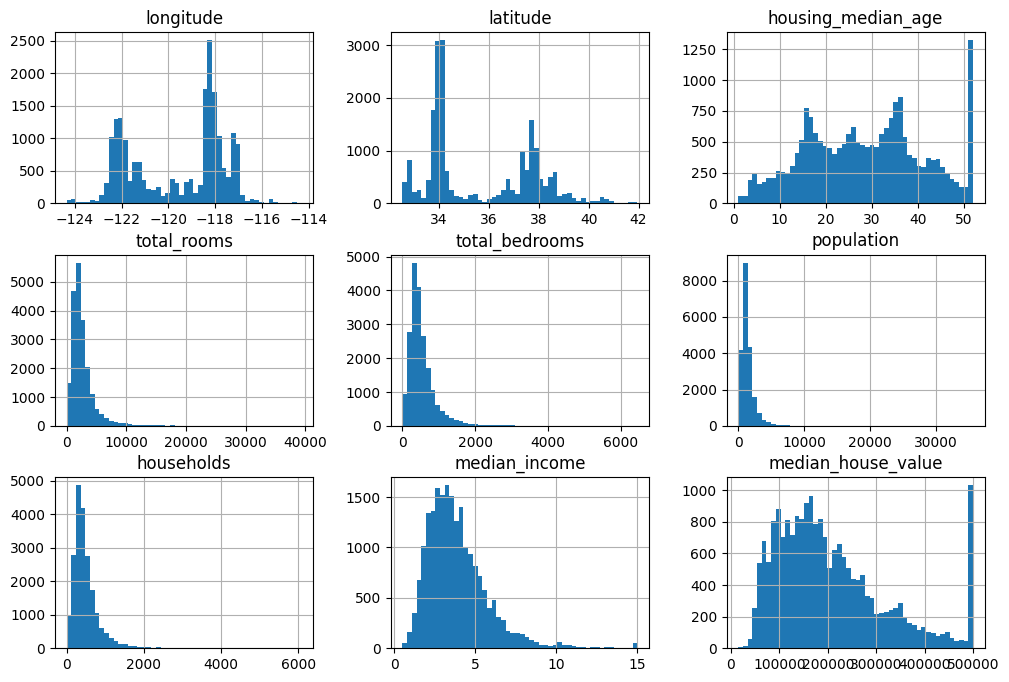

In [ ]:
# plotting a histogram for every numerical column in the dataset
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(12,8));

In [ ]:
# creating a income category coulumn for better representation of each stratum in the training dataset
import numpy as np
import pandas as pd

housing["income_cat"] = pd.cut(housing["median_income"], bins=[0.,1.5,3.,4.5,6,np.inf], labels=[1,2,3,4,5])

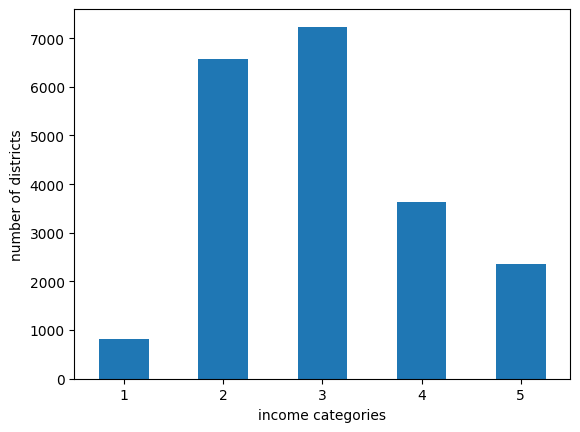

In [ ]:
housing["income_cat"].value_counts().sort_index().plot.bar()
plt.xticks(rotation=0)
plt.xlabel("income categories")
plt.ylabel("number of districts");

In [ ]:
from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(
housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

In [ ]:
print(strat_test_set["income_cat"].value_counts() / len(strat_test_set))

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64


In [ ]:
for set_ in (strat_train_set, strat_test_set):
  set_.drop("income_cat", axis=1, inplace=True)

In [ ]:
# creating a copy of the training set for exploration and visualization
housing = strat_train_set.copy()

In [ ]:
print(housing.head())

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096    -122.42     37.80                52.0       3321.0          1115.0   
14973    -118.38     34.14                40.0       1965.0           354.0   
3785     -121.98     38.36                33.0       1083.0           217.0   
14689    -117.11     33.75                17.0       4174.0           851.0   
20507    -118.15     33.77                36.0       4366.0          1211.0   

       population  households  median_income  median_house_value  \
13096      1576.0      1034.0         2.0987            458300.0   
14973       666.0       357.0         6.0876            483800.0   
3785        562.0       203.0         2.4330            101700.0   
14689      1845.0       780.0         2.2618             96100.0   
20507      1912.0      1172.0         3.5292            361800.0   

      ocean_proximity  
13096        NEAR BAY  
14973       <1H OCEAN  
3785           INLAND  
14689          INLAN

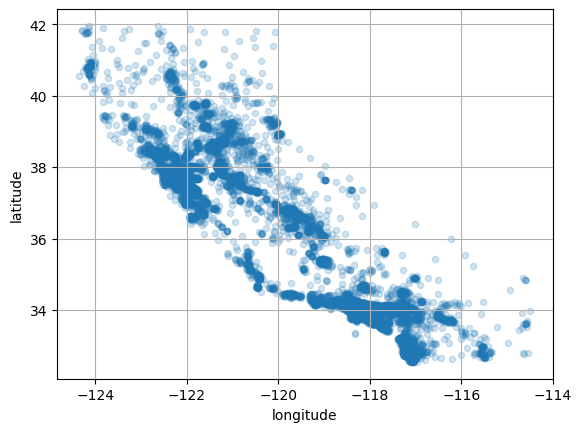

In [ ]:
# creating a scatter plot of latitude and longitude
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2);

<Axes: xlabel='longitude', ylabel='latitude'>

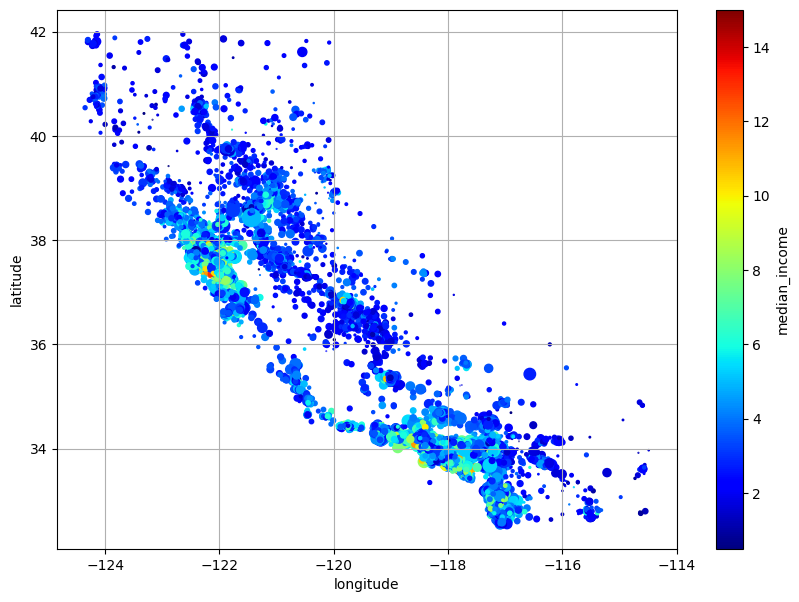

In [ ]:
# creating a scatter plot of latitude and longitude along with population size as size of circles (data points) and colors representing the median income of the districts
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, s=housing["population"]/100, c="median_income", cmap="jet", figsize=(10,7))

In [ ]:
# calculating correlation coefficients of every column of the dataset relative to median house value
corr_matrix = housing.iloc[:,:-1].corr()
print(corr_matrix)

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924213           -0.102937     0.044558   
latitude            -0.924213  1.000000            0.005692    -0.036753   
housing_median_age  -0.102937  0.005692            1.000000    -0.361710   
total_rooms          0.044558 -0.036753           -0.361710     1.000000   
total_bedrooms       0.068210 -0.066391           -0.317978     0.930076   
population           0.104236 -0.115677           -0.301906     0.863967   
households           0.054261 -0.071604           -0.300075     0.916143   
median_income       -0.016542 -0.078137           -0.127043     0.197720   
median_house_value  -0.050859 -0.139584            0.102175     0.137455   

                    total_bedrooms  population  households  median_income  \
longitude                 0.068210    0.104236    0.054261      -0.016542   
latitude                 -0.066391   -0.115677   -0.071604      -0.078137   
housing_

In [ ]:
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64


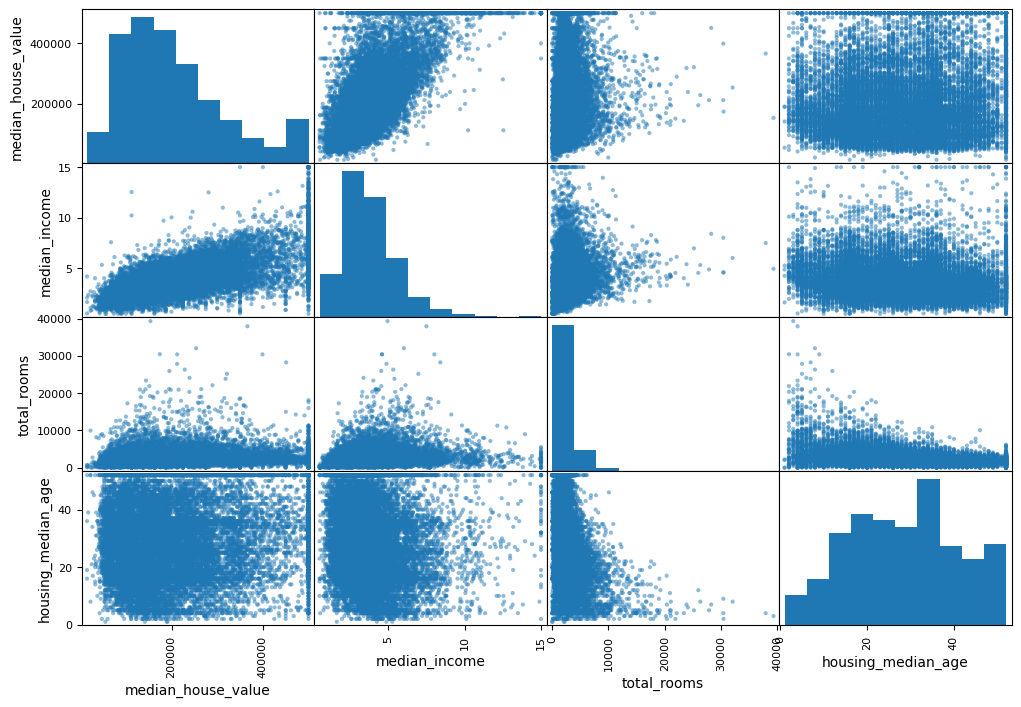

In [ ]:
# creating a scatter matrix for most correlated columns to median housing price
from pandas.plotting import scatter_matrix

cols = ["median_house_value","median_income","total_rooms","housing_median_age"]
scatter_matrix(housing[cols], figsize=(12,8))
plt.show()

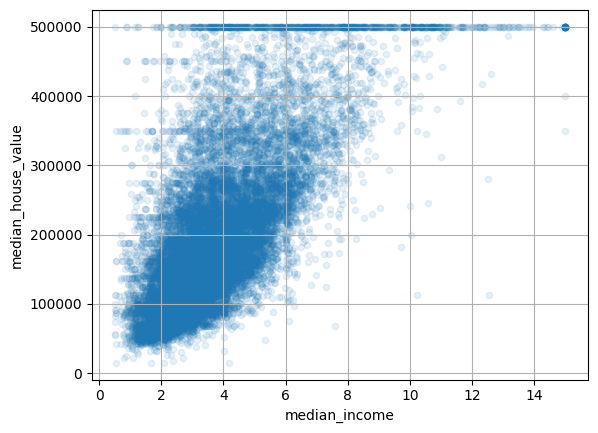

In [ ]:
# creating a scatter plot of median house value vs median income since it seems to be the most correlated numerical attribute
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, grid=True)
plt.show()

In [ ]:
# creating some attribute combinations
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [ ]:
print(housing.head())

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096    -122.42     37.80                52.0       3321.0          1115.0   
14973    -118.38     34.14                40.0       1965.0           354.0   
3785     -121.98     38.36                33.0       1083.0           217.0   
14689    -117.11     33.75                17.0       4174.0           851.0   
20507    -118.15     33.77                36.0       4366.0          1211.0   

       population  households  median_income  median_house_value  \
13096      1576.0      1034.0         2.0987            458300.0   
14973       666.0       357.0         6.0876            483800.0   
3785        562.0       203.0         2.4330            101700.0   
14689      1845.0       780.0         2.2618             96100.0   
20507      1912.0      1172.0         3.5292            361800.0   

      ocean_proximity  rooms_per_house  bedrooms_ratio  people_per_house  
13096        NEAR BAY         3.211799   

In [ ]:
corr_matrix = housing.corr(numeric_only=True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64


In [ ]:
# preparing data for machine learning algorithms
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [ ]:
# cleaning the data

# handling missing values
# filling median at places with missing values

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [ ]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [ ]:
housing_num.median().values

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [ ]:
X = imputer.transform(housing_num)

In [ ]:
print(X)

[[-1.2242e+02  3.7800e+01  5.2000e+01 ...  1.5760e+03  1.0340e+03
   2.0987e+00]
 [-1.1838e+02  3.4140e+01  4.0000e+01 ...  6.6600e+02  3.5700e+02
   6.0876e+00]
 [-1.2198e+02  3.8360e+01  3.3000e+01 ...  5.6200e+02  2.0300e+02
   2.4330e+00]
 ...
 [-1.1706e+02  3.2590e+01  1.3000e+01 ...  2.8140e+03  7.6000e+02
   4.0616e+00]
 [-1.1840e+02  3.4060e+01  3.7000e+01 ...  1.7250e+03  8.3800e+02
   4.1455e+00]
 [-1.2241e+02  3.7660e+01  4.4000e+01 ...  6.8200e+02  2.1200e+02
   3.2833e+00]]


In [ ]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
index=housing_num.index)

In [ ]:
print(housing_tr.head(), "\n")
print(housing_tr.isna().sum())

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096    -122.42     37.80                52.0       3321.0          1115.0   
14973    -118.38     34.14                40.0       1965.0           354.0   
3785     -121.98     38.36                33.0       1083.0           217.0   
14689    -117.11     33.75                17.0       4174.0           851.0   
20507    -118.15     33.77                36.0       4366.0          1211.0   

       population  households  median_income  
13096      1576.0      1034.0         2.0987  
14973       666.0       357.0         6.0876  
3785        562.0       203.0         2.4330  
14689      1845.0       780.0         2.2618  
20507      1912.0      1172.0         3.5292   

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
dtype: int64


In [ ]:
# one hot encoding for ocean proximity column values
from sklearn.preprocessing import OneHotEncoder

housing_cat = housing[["ocean_proximity"]]
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
print(housing_cat_1hot[:5])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (5, 5)>
  Coords	Values
  (0, 3)	1.0
  (1, 0)	1.0
  (2, 1)	1.0
  (3, 1)	1.0
  (4, 4)	1.0


In [ ]:
# feature scaling
# most common methods : min-max scaling (normalization) and standardization

# min max scaling
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1,1))  # if we want to have a feature range of -1 to 1 instead of 0 to 1
housing_min_max_scaled = min_max_scaler.fit_transform(housing_num)
print(housing_num.head(), "\n")
print(housing_min_max_scaled[:5])

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096    -122.42     37.80                52.0       3321.0          1115.0   
14973    -118.38     34.14                40.0       1965.0           354.0   
3785     -121.98     38.36                33.0       1083.0           217.0   
14689    -117.11     33.75                17.0       4174.0           851.0   
20507    -118.15     33.77                36.0       4366.0          1211.0   

       population  households  median_income  
13096      1576.0      1034.0         2.0987  
14973       666.0       357.0         6.0876  
3785        562.0       203.0         2.4330  
14689      1845.0       780.0         2.2618  
20507      1912.0      1172.0         3.5292   

[[-0.60851927  0.11702128  1.         -0.83117147 -0.64116605 -0.80701754
  -0.61433638 -0.7794789 ]
 [ 0.21095335 -0.66170213  0.52941176 -0.90014752 -0.88629409 -0.91866029
  -0.86708979 -0.22929339]
 [-0.51926978  0.23617021  0.25490196 -

In [ ]:
# standardization
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
housing_standardized = standard_scaler.fit_transform(housing_num)  # performs : (x(data point) - u(mean)) / (sigma (standard deviation))
print(housing_num.head())
print(housing_standardized[:5])

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096    -122.42     37.80                52.0       3321.0          1115.0   
14973    -118.38     34.14                40.0       1965.0           354.0   
3785     -121.98     38.36                33.0       1083.0           217.0   
14689    -117.11     33.75                17.0       4174.0           851.0   
20507    -118.15     33.77                36.0       4366.0          1211.0   

       population  households  median_income  
13096      1576.0      1034.0         2.0987  
14973       666.0       357.0         6.0876  
3785        562.0       203.0         2.4330  
14689      1845.0       780.0         2.2618  
20507      1912.0      1172.0         3.5292  
[[-1.42303652  1.0136059   1.86111875  0.31191221  1.35909429  0.13746004
   1.39481249 -0.93649149]
 [ 0.59639445 -0.702103    0.90762971 -0.30861991 -0.43635598 -0.69377062
  -0.37348471  1.17194198]
 [-1.2030985   1.27611874  0.35142777 -0.

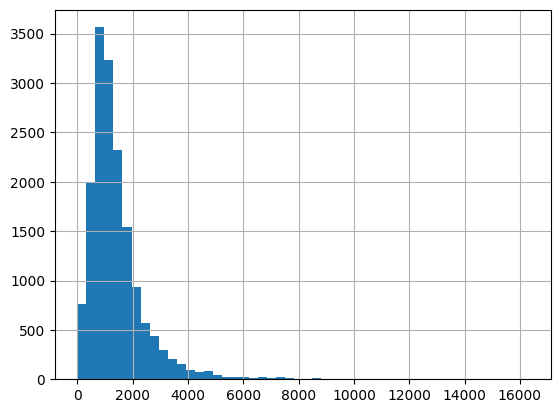

In [ ]:
# transforming features with heavy tail
housing_num["population"].hist(bins=50);

<Axes: >

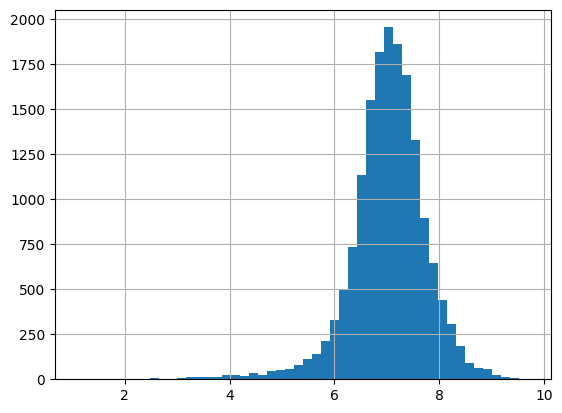

In [ ]:
np.log(housing_num["population"]).hist(bins=50)  # results to a more bell shaped gaussian distribution like curve efficient for ML models

In [ ]:
# scaling label values

# process:
# scaling label values using standard scaler
# fitting a linear regression model on the features data
# getting scaled predictions
# transforming the predictions back to original scale using inverse_transform() method

# print(housing.head)
# print(housing_labels)

from sklearn.linear_model import LinearRegression
target_scaler = StandardScaler()

housing_labels_scaled = target_scaler.fit_transform(housing_labels.to_frame())  # scaled label values using standard scaler
model = LinearRegression()
model.fit(housing[["median_income"]], housing_labels_scaled)  # fitting a linear regression model using the scaled label values

new_data = housing[["median_income"]].iloc[:5]
scaled_predictions = model.predict(new_data)  # getting scaled prediction values
predictions = target_scaler.inverse_transform(scaled_predictions)  # transforming the scaled predictions back
print(housing[["median_income"]][:5], "\n")
print(predictions[:5])

       median_income
13096         2.0987
14973         6.0876
3785          2.4330
14689         2.2618
20507         3.5292 

[[131997.15275877]
 [299359.35844434]
 [146023.37185694]
 [138840.33653057]
 [192016.61557639]]


In [ ]:
# alternative way to use scaled label values along with automatic inverse transform using a predefined function
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(), transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_labels)
predictions = model.predict(new_data)

print(predictions)

[131997.15275877 299359.35844434 146023.37185694 138840.33653057
 192016.61557639]


Transformation Pipelines

In [ ]:
# creating transformation pipelines
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("impute",SimpleImputer(strategy="mean")),
    ("scale",StandardScaler())
])

pipeline

Pipeline(steps=[('impute', SimpleImputer()), ('scale', StandardScaler())])

In [ ]:
housing_piped = pipeline.fit_transform(housing_num)
print(housing_piped[:5], "\n")
# df = pd.DataFrame(housing_piped, index=housing.index, columns=housing_num.columns)
# print(df.head())

housing_piped_df = pd.DataFrame(housing_piped, columns=pipeline.get_feature_names_out(), index=housing_num.index)
print(housing_piped_df.head())

[[-1.42303652  1.0136059   1.86111875  0.31191221  1.36606149  0.13746004
   1.39481249 -0.93649149]
 [ 0.59639445 -0.702103    0.90762971 -0.30861991 -0.4385929  -0.69377062
  -0.37348471  1.17194198]
 [-1.2030985   1.27611874  0.35142777 -0.71224036 -0.76347812 -0.78876841
  -0.77572662 -0.75978881]
 [ 1.23121557 -0.88492444 -0.91989094  0.70226169  0.74000531  0.38317548
   0.73137454 -0.85028088]
 [ 0.71136206 -0.87554898  0.58980003  0.79012465  1.59371829  0.44437597
   1.75526303 -0.18036472]] 

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096  -1.423037  1.013606            1.861119     0.311912        1.366061   
14973   0.596394 -0.702103            0.907630    -0.308620       -0.438593   
3785   -1.203098  1.276119            0.351428    -0.712240       -0.763478   
14689   1.231216 -0.884924           -0.919891     0.702262        0.740005   
20507   0.711362 -0.875549            0.589800     0.790125        1.593718   

       population

In [ ]:
# creating a column Transformer to apply num_pipeline to numerical columns and cat_pipeline to categorical columns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

num_attrbs = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income']
cat_attrbs = ['ocean_proximity']

num_pipeline = Pipeline([
    ("impute",SimpleImputer(strategy="median")),
    ("scale",MinMaxScaler())
])

# cat_pipeline = Pipeline([
#     ("impute", SimpleImputer(strategy="most_frequent")),
#     ("encode", OneHotEncoder(handle_unknown="ignore"))
# ])

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attrbs),
    ("cat", cat_pipeline, cat_attrbs)
])

In [ ]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
(num_pipeline, make_column_selector(dtype_include=np.number)),
(cat_pipeline, make_column_selector(dtype_include=object)),
)

In [ ]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared_df = pd.DataFrame(housing_prepared, columns=preprocessing.get_feature_names_out(), index=housing.index)
print(housing_prepared_df[:5])
print(housing_prepared_df.columns)

       pipeline-1__longitude  pipeline-1__latitude  \
13096               0.195740              0.558511   
14973               0.605477              0.169149   
3785                0.240365              0.618085   
14689               0.734280              0.127660   
20507               0.628803              0.129787   

       pipeline-1__housing_median_age  pipeline-1__total_rooms  \
13096                        1.000000                 0.084414   
14973                        0.764706                 0.049926   
3785                         0.627451                 0.027494   
14689                        0.313725                 0.106109   
20507                        0.686275                 0.110992   

       pipeline-1__total_bedrooms  pipeline-1__population  \
13096                    0.179417                0.096491   
14973                    0.056853                0.040670   
3785                     0.034788                0.034290   
14689                    0.136898 

In [ ]:
# full transformation pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

def column_ratio(X):
  return X[:, [0]] / X[:, [1]]
def ratio_name(function_transformer, feature_names_in):
  return ["ratio"]  # feature names out
def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())

# cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)

default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())
preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        # ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline)  # one column remaining: housing_median_age

In [ ]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape

(16512, 16)

In [ ]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__longitude', 'remainder__latitude',
       'remainder__housing_median_age'], dtype=object)

Selecting and Training a model

In [ ]:
# training a linear regression model
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7ee...
                                                                   StandardScaler())]),
                                                  ['total_bedrooms',
                                                   'total_rooms', 'population',
                                                   'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7eec5645a600>)])),
                ('linearregression', LinearRegression())])

In [ ]:
housing_predictions = lin_reg.predict(housing)
print(housing_predictions[:5].round(-2))
print(housing_labels[:5].values)

[260100. 357900. 125800. 110000. 298900.]
[458300. 483800. 101700.  96100. 361800.]


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error

# lin_rmse = mean_squared_error(housing_labels, housing_predictions, squared=False)
lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
print(lin_rmse)

70630.22169174394


In [ ]:
# training a decision tree regressor
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7ee...
                                                  ['total_bedrooms',
                                                   'total_rooms', 'population',
                                                   'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7eec5645a600>)])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [ ]:
housing_predictions = tree_reg.predict(housing)
tree_rmse = root_mean_squared_error(housing_labels, housing_predictions)
print(housing_predictions[:5])
print(housing_labels[:5].values)
print(tree_rmse)

[458300. 483800. 101700.  96100. 361800.]
[458300. 483800. 101700.  96100. 361800.]
0.0


In [ ]:
# cross-validation to see if the model is fine or not
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)  # since cross_val_score expects a utility function (greater the better) rather than a cost function (lesser the better)
print(pd.Series(tree_rmses).describe())

count       10.000000
mean     70042.976853
std       2211.223510
min      67197.302832
25%      68117.719418
50%      70520.112088
75%      71261.203808
max      73874.610882
dtype: float64


In [ ]:
# training a random forest model
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing, RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)
print(pd.Series(forest_rmses).describe())

count       10.000000
mean     49632.089212
std       1020.064249
min      47620.869586
25%      49099.175089
50%      49749.949265
75%      50183.743922
max      51263.448191
dtype: float64


In [ ]:
# training random forest on training set and testing it
forest_reg.fit(housing, housing_labels)
housing_predictions = forest_reg.predict(housing)
random_forest_rmse = root_mean_squared_error(housing_labels, housing_predictions)
print(housing_predictions[:5])
print(housing_labels[:5].values)
print(random_forest_rmse)

[423125.05 479550.25 105234.   100904.   389306.07]
[458300. 483800. 101700.  96100. 361800.]
18469.486046590784


In [ ]:
# # grid search CV
# from sklearn.model_selection import GridSearchCV
# full_pipeline = Pipeline([
#     ("preprocessing", preprocessing),
#     ("random_forest", RandomForestRegressor(random_state=42)),
# ])
# param_grid = [
#     {'preprocessing__geo__n_clusters': [5, 8, 10],
#      'random_forest__max_features': [4, 6, 8]},
#     {'preprocessing__geo__n_clusters': [10, 15],
#      'random_forest__max_features': [6, 8, 10]},
# ]
# grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
#                            scoring='neg_root_mean_squared_error')
# grid_search.fit(housing, housing_labels)

In [ ]:
# # randomized search
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import randint
# param_distribs = {'preprocessing__geo__n_clusters': randint(low=3, high=50),
# 'random_forest__max_features': randint(low=2, high=20)}
# rnd_search = RandomizedSearchCV(
# full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
# scoring='neg_root_mean_squared_error', random_state=42)
# rnd_search.fit(housing, housing_labels)

In [ ]:
# X_test = strat_test_set.drop("median_house_value", axis=1)
# y_test = strat_test_set["median_house_value"].copy()
# final_predictions = final_model.predict(X_test)
# final_rmse = mean_squared_error(y_test, final_predictions, squared=False)
# print(final_rmse)  # prints 41424.40026462184

In [ ]:
# from scipy import stats
# confidence = 0.95
# squared_errors = (final_predictions - y_test) ** 2
# np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
# loc=squared_errors.mean(),
# scale=stats.sem(squared_errors)))

Excersises

In [ ]:
# End to End machine learning workflow from data preparation to model training and evaluation (linear regression)
# Workflow steps:
# 1. Framing the problem
#    ----what kind of supervision is needed
#    ----what is to be obtained as output and where will it be used
#    ----whether batch learning or online learning is preferred
#    ----whether instance based learning or model based learning is preferred
#    ----what task is required (such as classification for predicting a group/label or regression for predicting a numerical value, etc.)
# 2. Loading the dataset
# 3. Splitting the dataset into training and test set as the initial step only
# 4. Inspecting the dataset and understanding the features along with the labels (in this case of housing dataset)
# 5. Exploring data through visualization
# 6. Checking for correlations within data features and labels (as in this case of supervised learning)
# 7. Cleaning data
#    ----checking for missing values and deciding relevant imputation for them
#        ----mean/median/mode for numerical imputation
#        ----most frequent imputation for categorical or textual values
#    ----handling outliers
#        ----dropping outlier having data values
#        ----imputing outlier values with relevant values
# 8. Data Transformation
#    ----converting data to suitable format for usage of ML models
#        ----feature scaling : min-max scaling (normalization), standard scaler
#        ----converting categorical features to dummy variables : one-hot encoding, ordinal encoding, label encoding
#        ----converting skewed features to a more symmetrical pattern for better training and interpretation by ML models : using log function for right-skewed distributions, etc.
# (Data Cleaning and Data Transformation can be done through using scikit-learn's pipelines)
# 9. Training different models on the training set
# 10. Evaluating and fine-tuning models
#     ---- if say rmse (on training set) < rmse (on validation set say using k cross fold validation) : the model may be overfitting
#     ---- if rmse (on training set) and rmse (on validation set say using k cross fold validation) are both high values : the model may be underfitting
# 11. Use different models and evaluate the outputs
# 12. Choose the best performing one and then evaluate it on the test set
#     ----if it performs fine on the test set : can deploy it to a production environment
#     ----if it performs wrongly on the test set : can check for data mismatch between test set and valdidation set, add regularization if overfitting (if performing fine on validation set and not on test set), etc.

In [ ]:
# loading the dataset
# downloading the california housing dataset directly through a defined function

from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))
housing = load_housing_data()

In [ ]:
# loading first few rows of the dataset
print(housing.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [ ]:
# columns in the dataset:
# - longitude, latitude : represent the geographical information of california districts
# - housing_median_age : represents the median age of houses district-wise
# - total_rooms, total_bedrooms : represents total number of rooms and bedrooms district-wise
# - population : represents the total population of districts
# - households : represents the number of houses district-wise
# - median_income : represents the median income of people belonging to particular districts
# - median_house_value : represents the median price value of houses in districts
# - ocean_proximity : represents how much proximity is a particular district in accordance to the ocean

# features : longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income, ocean_proximity
# label : median_house_value

# problem:
# to predict exact numerical median house prices of districts when given the values of features such as latitude and longitude of the district, it's median housing age,
# total number of rooms and bedrooms the district has, households and ocean proximity.

# type of supervision required : supervised learning (since we already have labels in the data)
# batch/online learning : batch learning (that is one-go) at this time
# instance/model based : model based learning required
# task (out of supervised learning tasks : classification/regression): regression (since we have to predict numerical values of median house prices of districts)

In [ ]:
# getting description of the dataset's columns and missing values count, etc.
print(housing.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


In [ ]:
# printing number of null values column-wise
print(housing.isna().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [ ]:
# printing unique values and counts of the categorical column we have i.e ocean_proximity
print(housing["ocean_proximity"].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [ ]:
# getting a description about distribution of every numerical feature
print(housing.describe())

          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        296.00000

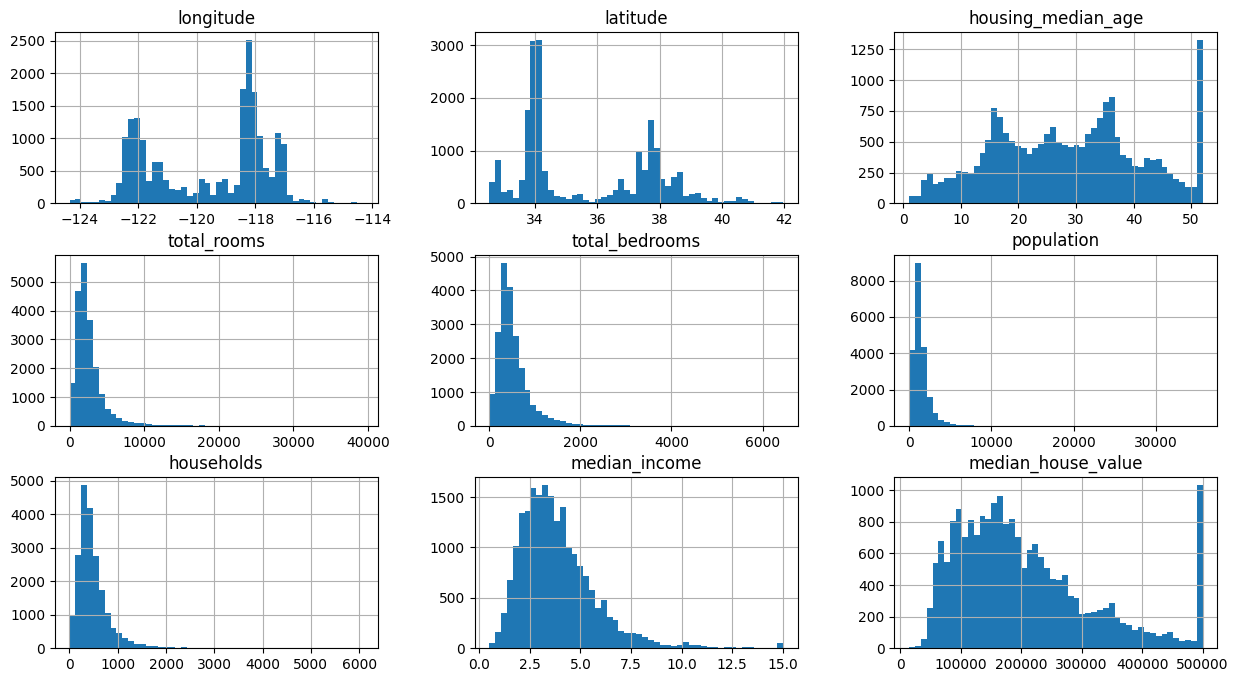

In [ ]:
# data exploration through visuals
# checking how the data is distributed through histograms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(15,8));

In [ ]:
# stratified sampling for median income feature since it seems to be an important feature for predicting median house value
# this ensures each category of median income is represented proportionally in the training and test sets

# creating an income category feature column
housing["income_cat"] = pd.cut(housing["median_income"], bins=[0.,1.5,3.,4.5,6,np.inf], labels=[1,2,3,4,5])
print(housing["income_cat"][:5])

0    5
1    5
2    5
3    4
4    3
Name: income_cat, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]


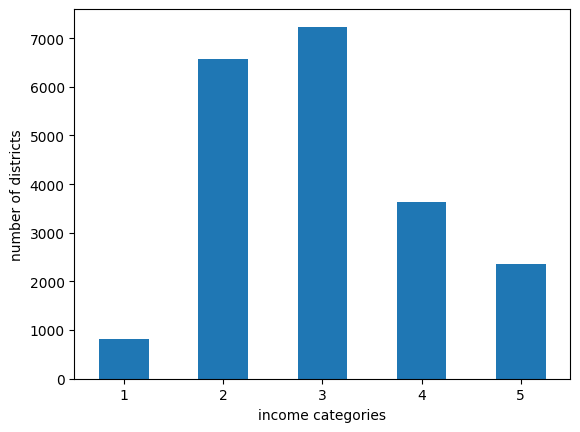

In [ ]:
housing["income_cat"].value_counts().sort_index(ascending=True).plot.bar();
plt.xticks(rotation=0)
plt.xlabel("income categories")
plt.ylabel("number of districts");

In [ ]:
# splitting the dataset into training and test sets
# also ensuring same proportion of income categories in training and test sets through the use of stratify parameter in the scikit-learn's train_test_split function
from sklearn.model_selection import train_test_split

housing_train_set, housing_test_set = train_test_split(housing, test_size = 0.2, stratify=housing["income_cat"], random_state=42)  # keeping test size as 20% of the whole dataset

In [ ]:
# exploring data through visuals and correlations

# creating a copy of training set for more visuals
housing = housing_train_set.copy()

print(housing.head())

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096    -122.42     37.80                52.0       3321.0          1115.0   
14973    -118.38     34.14                40.0       1965.0           354.0   
3785     -121.98     38.36                33.0       1083.0           217.0   
14689    -117.11     33.75                17.0       4174.0           851.0   
20507    -118.15     33.77                36.0       4366.0          1211.0   

       population  households  median_income  median_house_value  \
13096      1576.0      1034.0         2.0987            458300.0   
14973       666.0       357.0         6.0876            483800.0   
3785        562.0       203.0         2.4330            101700.0   
14689      1845.0       780.0         2.2618             96100.0   
20507      1912.0      1172.0         3.5292            361800.0   

      ocean_proximity income_cat  
13096        NEAR BAY          2  
14973       <1H OCEAN          5  
3785       

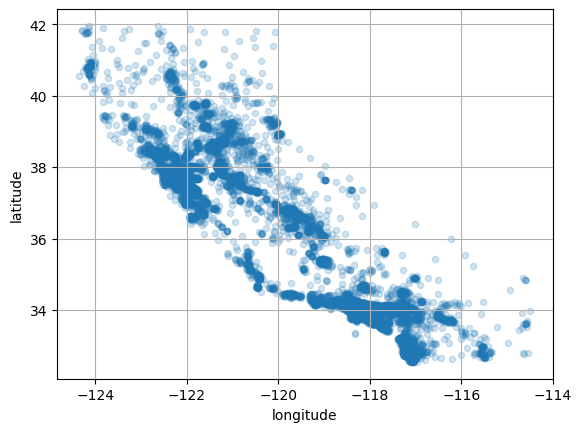

In [ ]:
# creating a scatter plot for visualizing the geographical data
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.2, grid=True);

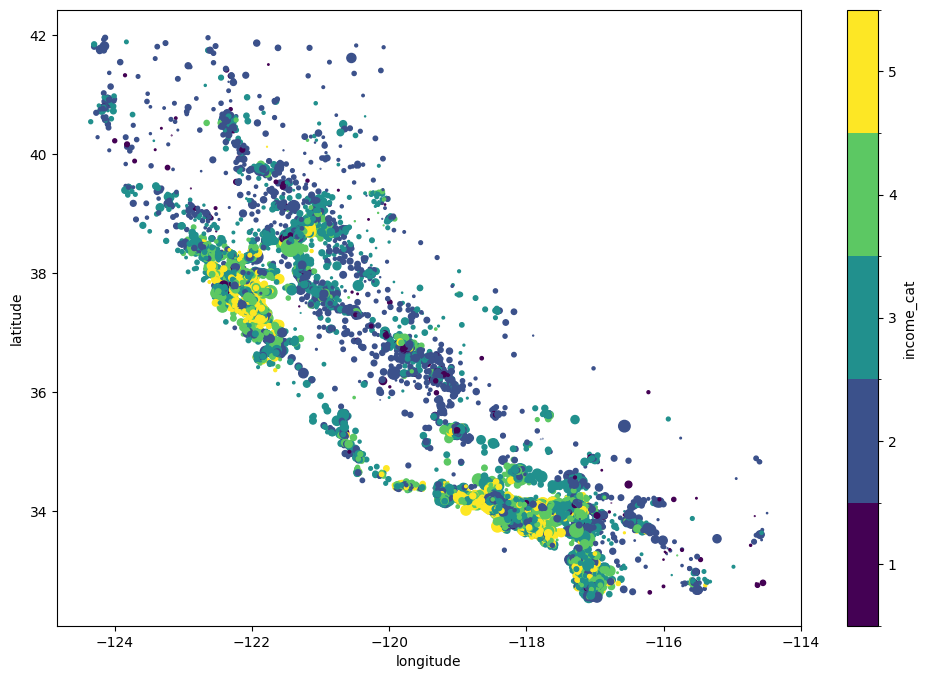

In [ ]:
# creating a scatter plot of latitude and longitude along with visualizing population as size of districts and income categories as color of a particular scale range

housing.plot(kind="scatter", x="longitude", y="latitude", s=housing["population"]/100, c="income_cat", cmap="viridis", figsize=(12,8));

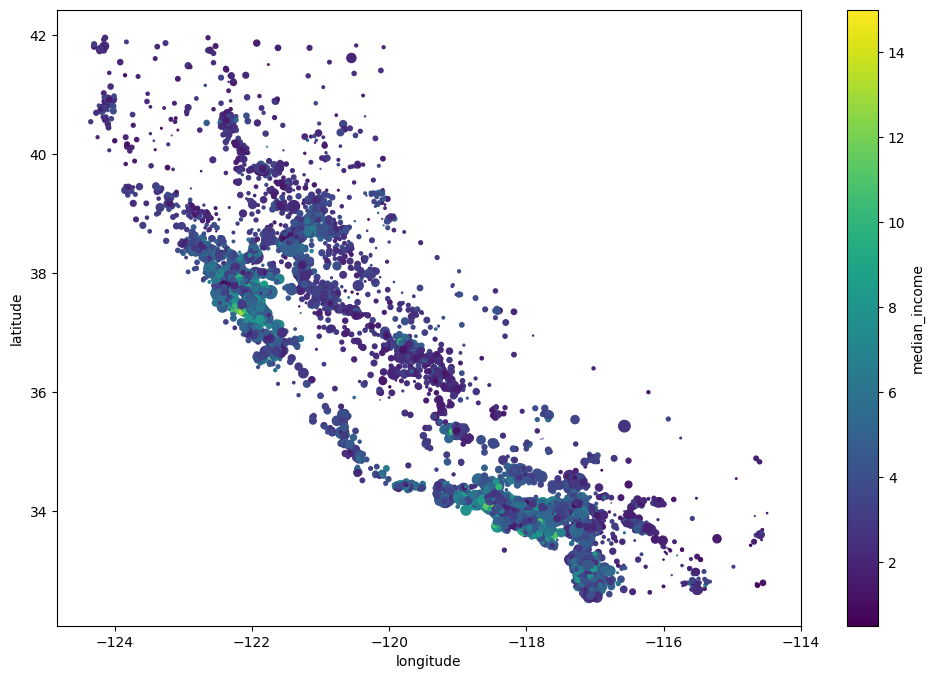

In [ ]:
# creating a scatter plot of latitude and longitude along with visualizing population as size of districts and median income as color of a particular scale range

housing.plot(kind="scatter", x="longitude", y="latitude", s=housing["population"]/100, c="median_income", cmap="viridis", figsize=(12,8));

In [ ]:
# checking correlations between columns of the dataset
from pandas.plotting import scatter_matrix

# scatter_matrix(housing) results to a large number of plots b/w all the columns
# checking correlations b/w features and the label (pearson's correlation coefficient)
housing_numeric_cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value']
corr_matrix = housing[housing_numeric_cols].corr()
# print(corr_matrix)  # prints the whole correlation matrix including correlations of every column with each other
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64


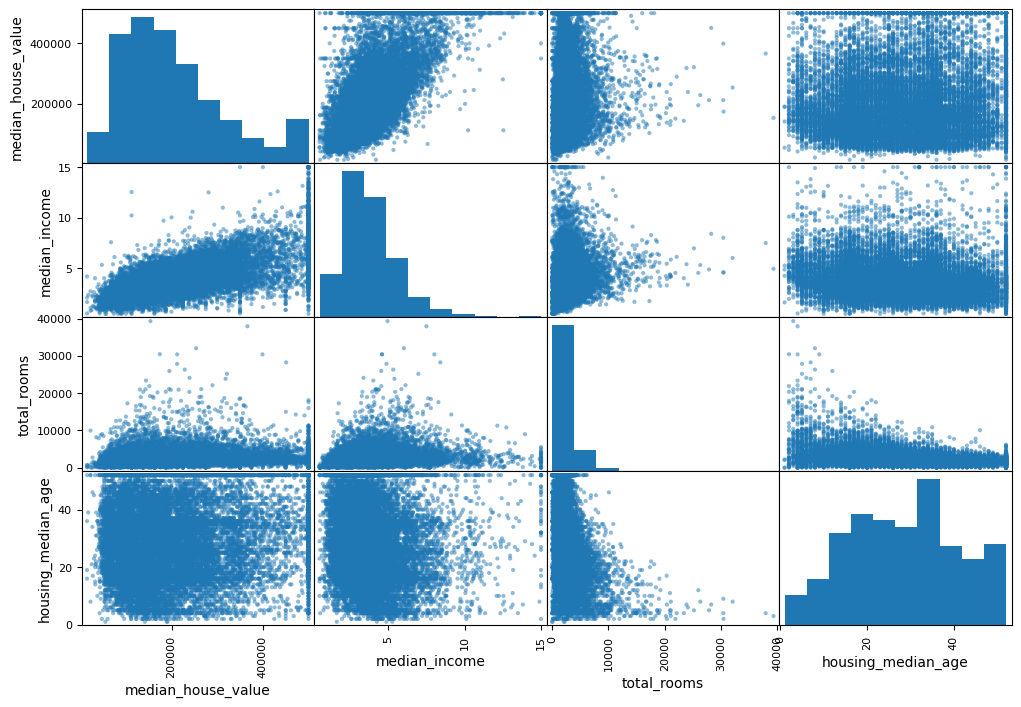

In [ ]:
# now creating a scatter matrix of top columns correlating with the label
corr_cols = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']
scatter_matrix(housing[corr_cols], figsize=(12,8));

# to only print the first row of the scatter matrix (that is of the median house value as the y axis values and other features having x axes values)
# axes = scatter_matrix(housing[corr_cols], figsize=(12,8));
# first_row_axes = axes[0, :]

# # To explicitly hide the others, you need to turn them off:
# for ax in axes.flatten():
#     if ax not in first_row_axes:
#         ax.set_visible(False)

# plt.show()

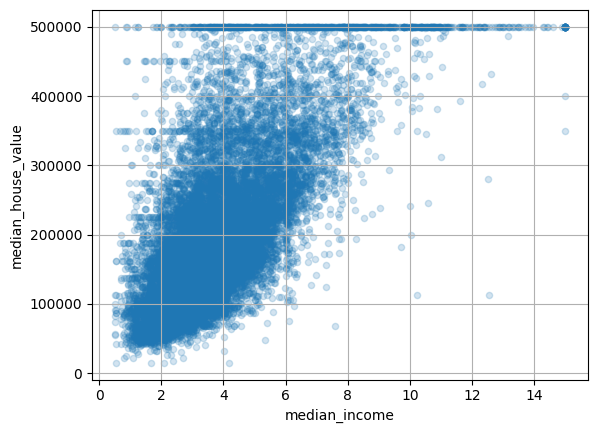

In [ ]:
# creating a scatter plot b/w median income and median house value
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.2, grid=True);

<Axes: xlabel='median_income', ylabel='median_house_value'>

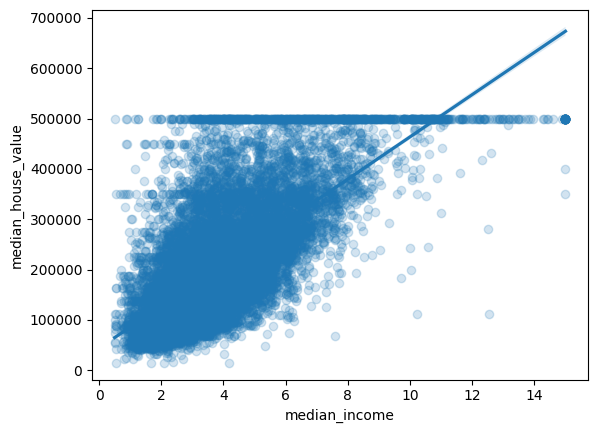

In [ ]:
# creating a regression plot through seaborn of median income vs median house value
import seaborn as sns
sns.regplot(housing, x="median_income", y="median_house_value", scatter_kws={'alpha':0.2})

In [ ]:
print(housing.head())

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096    -122.42     37.80                52.0       3321.0          1115.0   
14973    -118.38     34.14                40.0       1965.0           354.0   
3785     -121.98     38.36                33.0       1083.0           217.0   
14689    -117.11     33.75                17.0       4174.0           851.0   
20507    -118.15     33.77                36.0       4366.0          1211.0   

       population  households  median_income  median_house_value  \
13096      1576.0      1034.0         2.0987            458300.0   
14973       666.0       357.0         6.0876            483800.0   
3785        562.0       203.0         2.4330            101700.0   
14689      1845.0       780.0         2.2618             96100.0   
20507      1912.0      1172.0         3.5292            361800.0   

      ocean_proximity income_cat  
13096        NEAR BAY          2  
14973       <1H OCEAN          5  
3785       

In [ ]:
# removing the income_cat column now since it isn't required now
housing.drop("income_cat", axis=1, inplace=True)

In [ ]:
print(housing.head())

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096    -122.42     37.80                52.0       3321.0          1115.0   
14973    -118.38     34.14                40.0       1965.0           354.0   
3785     -121.98     38.36                33.0       1083.0           217.0   
14689    -117.11     33.75                17.0       4174.0           851.0   
20507    -118.15     33.77                36.0       4366.0          1211.0   

       population  households  median_income  median_house_value  \
13096      1576.0      1034.0         2.0987            458300.0   
14973       666.0       357.0         6.0876            483800.0   
3785        562.0       203.0         2.4330            101700.0   
14689      1845.0       780.0         2.2618             96100.0   
20507      1912.0      1172.0         3.5292            361800.0   

      ocean_proximity  
13096        NEAR BAY  
14973       <1H OCEAN  
3785           INLAND  
14689          INLAN

In [ ]:
# feature engineering

# creating features that have better values to predict median house prices : rooms per household, bedrooms per total rooms, population per household
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [ ]:
print(housing.head())

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096    -122.42     37.80                52.0       3321.0          1115.0   
14973    -118.38     34.14                40.0       1965.0           354.0   
3785     -121.98     38.36                33.0       1083.0           217.0   
14689    -117.11     33.75                17.0       4174.0           851.0   
20507    -118.15     33.77                36.0       4366.0          1211.0   

       population  households  median_income  median_house_value  \
13096      1576.0      1034.0         2.0987            458300.0   
14973       666.0       357.0         6.0876            483800.0   
3785        562.0       203.0         2.4330            101700.0   
14689      1845.0       780.0         2.2618             96100.0   
20507      1912.0      1172.0         3.5292            361800.0   

      ocean_proximity  rooms_per_house  bedrooms_ratio  people_per_house  
13096        NEAR BAY         3.211799   

In [ ]:
# checking again the correlation of features along with the label
housing_numeric_cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'rooms_per_house', 'bedrooms_ratio', 'people_per_house']
corr_matrix = housing[housing_numeric_cols].corr()
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64


In [ ]:
# separating features and label values for usage of ML models, algorithms and techniques
housing = housing_train_set.drop("median_house_value", axis=1)  # creates a copy of the resultant dataframe after dropping the specified column
housing_labels = housing_train_set["median_house_value"].copy()

In [ ]:
# cleaning and data transformation through the use of scikit-learn's pipelines

# pipeline steps to include:
# - imputing missing values in numerical columns with the median (here, for total bedrooms column)
# - imputing missing values in categorical columns with the most frequent category
# - feature scaling using standard scaler for numerical columns
# - one-hot encoding here for categorical columns (ocean proximity)
# (imputing may be done through SimpleImputer and encoding through the use of OneHotEncoder within the scikit-learn library)

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_transformer, make_column_selector

num_attrbs = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'rooms_per_house',
       'bedrooms_ratio', 'people_per_house']

cat_attrbs = ['ocean_proximity']

# defining a pipeline for preprocessing of numerical columns

# preprocessing_num = Pipeline([
#     ("imputer", SimpleImputer(strategy="median")),
#     ("scaler", StandardScaler())
# ])

preprocessing_num = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

# defining a pipeline for preprocessing of categorical columns

# preprocessing_cat = Pipeline([
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("encoder", OneHotEncoder(handle_unknown="ignore"))
# ])

preprocessing_cat = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

# defining a column transformer for dispatching particular pipelines to relevant columns
# preprocessing = ColumnTransformer([
#     ("numerical", preprocessing_num, num_attrbs),
#     ("categorical", preprocessing_cat, cat_attrbs)
# ])

preprocessing = make_column_transformer(
    (preprocessing_num, make_column_selector(dtype_include=np.number)),
    (preprocessing_cat, make_column_selector(dtype_include=object))
)

In [ ]:
# full end to end pipeline:
# - creating features : rooms per household, bedrooms ratio and people per house
# - cleaning and transformation for numerical columns:
#   -- if right skewed columns : log distribution function + median imputation + standard scaler
#   -- if simple distribution column : median imputation + standard scaler
# - cleaning and transformation for categorical columns:
#   -- most frequent imputation + one hot encoder

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer


# creating a custom defined function for getting ratio between specific columns
def ratio_columns(X):
  return X[:,[0]]/X[:,[1]]

def ratio_name(function_transformer, feature_names_in):
  return ["ratio"]  # feature names out

# creating a ratio pipeline for getting all the ratio features
ratio_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(ratio_columns, feature_names_out=ratio_name),
    StandardScaler()
)

# creating a log pipeline
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

# creating a pipeline for preprocessing
# - numerical columns:
#   -- ratio_pipeline : for creating ratio features (impute + function transformer with ratio function + standard scaler)
#   -- log_pipeline : for log transformations (impute + function transformer with log function + standard scaler)
#   -- default_num_pipeline : for remaining columns (impute + standard scaler)
# - categorical columns:
#   -- cat_pipeline : for categorical columns (impute as most frequent + one hot encoder)

preprocessing = ColumnTransformer([
    ("rooms_per_household", ratio_pipeline, ["total_rooms", "households"]),
    ("bedrooms_ratio", ratio_pipeline, ["total_bedrooms", "total_rooms"]),
    ("people_per_house", ratio_pipeline, ["population", "households"]),
    ("log", log_pipeline, ['total_rooms','total_bedrooms', 'population', 'households', 'median_income']),
    # ("cat", cat_pipeline, ['ocean_proximity'])
    ("cat", cat_pipeline, make_column_selector(dtype_include=object))
],
    remainder=default_num_pipeline)  # column remaining : housing_median_age

In [ ]:
# fitting and transforming housing df using preprocessing pipeline
housing_preprocessed = preprocessing.fit_transform(housing)
print(housing_preprocessed[:5])

[[-0.86602737  1.84662439 -0.33020372  0.63853808  1.33150164  0.45731294
   1.31789337 -1.07854723  0.          0.          0.          1.
   0.         -1.42303652  1.0136059   1.86111875 -0.95468705]
 [ 0.0245495  -0.5081207  -0.25361631 -0.06408519 -0.25592046 -0.71371985
  -0.14480069  1.23176121  1.          0.          0.          0.
   0.          0.59639445 -0.702103    0.90762971  1.89007821]
 [-0.04119332 -0.20215476 -0.05104091 -0.86151    -0.93172887 -0.94440512
  -0.91968744 -0.79246356  0.          1.          0.          0.
   0.         -1.2030985   1.27611874  0.35142777 -0.95468705]
 [-0.03485833 -0.14900562 -0.14147547  0.94466294  0.95741335  0.67164902
   0.92993325 -0.93530826  0.          1.          0.          0.
   0.          1.23121557 -0.88492444 -0.91989094 -0.95468705]
 [-0.66655412  0.96320807 -0.30614815  1.00488661  1.44586957  0.72016691
   1.49034184 -0.01866707  0.          0.          0.          0.
   1.          0.71136206 -0.87554898  0.5898000

In [ ]:
housing_preprocessed_df = pd.DataFrame(housing_preprocessed, columns=preprocessing.get_feature_names_out(), index=housing.index)
print(housing_preprocessed_df.head())

       rooms_per_household__ratio  bedrooms_ratio__ratio  \
13096                   -0.866027               1.846624   
14973                    0.024550              -0.508121   
3785                    -0.041193              -0.202155   
14689                   -0.034858              -0.149006   
20507                   -0.666554               0.963208   

       people_per_house__ratio  log__total_rooms  log__total_bedrooms  \
13096                -0.330204          0.638538             1.331502   
14973                -0.253616         -0.064085            -0.255920   
3785                 -0.051041         -0.861510            -0.931729   
14689                -0.141475          0.944663             0.957413   
20507                -0.306148          1.004887             1.445870   

       log__population  log__households  log__median_income  \
13096         0.457313         1.317893           -1.078547   
14973        -0.713720        -0.144801            1.231761   
3785       

In [ ]:
print(housing_preprocessed_df.shape)

(16512, 17)


In [ ]:
# training a linear regression model on the training data
from sklearn.linear_model import LinearRegression

# defining a pipeline that performs the preprocessing pipeline as well as fits a linear regression model on the data
lin_reg = make_pipeline(
    preprocessing,
    LinearRegression()
)

lin_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('rooms_per_household',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_...
                                                                   StandardScaler())]),
                                                  ['total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b33fc080440>)])),
                ('linearregression', LinearRegression())])

In [ ]:
housing_predictions = lin_reg.predict(housing)

print(housing_predictions[:5].round(2))
print(housing_labels[:5].values)

[263793.61 374656.   117268.69 103172.61 304595.05]
[458300. 483800. 101700.  96100. 361800.]


In [ ]:
# calculating root mean squared error (rmse) to evaluate outputs of different models
from sklearn.metrics import root_mean_squared_error

rmse_score = root_mean_squared_error(housing_labels, housing_predictions)
print("rmse (linear regression model):", rmse_score)

rmse (linear regression model): 68532.02334551583


In [ ]:
# performing k-fold cross-validation and getting the mean rmse value
# cross-validation to see if the model is fine or not
from sklearn.model_selection import cross_val_score

lin_reg_rmses = -cross_val_score(lin_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)  # since cross_val_score expects a utility function (greater the better) rather than a cost function (lesser the better)
print(pd.Series(lin_reg_rmses).describe())

count       10.000000
mean     69493.397682
std       3254.447073
min      66098.882468
25%      67781.763213
50%      68733.271028
75%      69568.179017
max      77867.558500
dtype: float64


In [ ]:
# training a decision tree regressor model on the training set and then evaluating it based on rmse
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(
    preprocessing,
    DecisionTreeRegressor()
)

tree_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('rooms_per_household',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_...
                                                  ['total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b33fc080440>)])),
                ('decisiontreeregressor', DecisionTreeRegressor())])

In [ ]:
housing_predictions = tree_reg.predict(housing)

print(housing_predictions[:5].round(2))
print(housing_labels[:5].values)

[458300. 483800. 101700.  96100. 361800.]
[458300. 483800. 101700.  96100. 361800.]


In [ ]:
print("rmse (decision tree):", root_mean_squared_error(housing_labels, housing_predictions))

rmse (decision tree): 0.0


In [ ]:
# performing k-fold cross validation to check how the model performs using validation set
tree_rmses = -cross_val_score(tree_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)
print(pd.Series(tree_rmses).describe())

count       10.000000
mean     69279.886509
std       2140.361893
min      65518.024402
25%      68452.292996
50%      69154.512753
75%      70654.196155
max      72410.564926
dtype: float64


In [ ]:
# training random forest regressor model and evaluating it based on rmse
from sklearn.ensemble import RandomForestRegressor

random_forest_reg = make_pipeline(preprocessing, RandomForestRegressor())
random_forest_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('rooms_per_household',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_...
                                                  ['total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b33fc080440>)])),
                ('randomforestregressor', RandomForestRegressor())])

In [ ]:
housing_predictions = random_forest_reg.predict(housing)

print(housing_predictions[:5].round(2))
print(housing_labels[:5].values)

print("rmse (random forest):", root_mean_squared_error(housing_labels, housing_predictions))

[423373.11 484493.27 105518.    97948.   380645.1 ]
[458300. 483800. 101700.  96100. 361800.]
rmse (random forest): 18590.58977688131


In [ ]:
# performing k-fold cross validation and checking the mean rmse
random_forest_rmses = -cross_val_score(random_forest_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)
print(pd.Series(random_forest_rmses).describe())

count       10.000000
mean     49810.753889
std       1061.530255
min      47550.903784
25%      49370.455958
50%      50000.823107
75%      50224.446190
max      51218.096343
dtype: float64


In [ ]:
# performing hyperparamter tuning taking random forest model as the choice out of all the models tested on training data (on the basis of full training data rmse and k-fold cross validation score)

# implementing grid search CV
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42))
])

# defining the parameter grid for grid search CV
# checks every combination for:
# - remainder impute strategy as median or mean + cat impute strategy as most frequent or constant + random forest max features out of [4,6,8]
# - remainder impute strategy as median or mean + log function transformer function as np.log1p or np.log or None + random forest max features out of [4,6,8]
# - remainder impute strategy as median or mean + log function transformer function as np.log1p or np.log or None + random forest max features out of [6,8,10]

# param_grid = [
#     {
#         "preprocessing__remainder__simpleimputer__strategy":['median','mean'],
#         "preprocessing__cat__simpleimputer__strategy":['most_frequent','constant'],
#         "random_forest__max_features":[4,6,8]
#     },
#     {
#         "preprocessing__remainder__simpleimputer__strategy":['median', 'mean'],
#         "preprocessing__log__functiontransformer__func":[np.log1p, np.log, None],
#         "random_forest__max_features":[4,6,8]
#     },
#     {
#         "preprocessing__remainder__simpleimputer__strategy":['median', 'mean'],
#         "preprocessing__log__functiontransformer__func":[np.log1p, np.log, None],
#         "random_forest__max_features":[6,8,10]
#     }
# ]

param_grid = [
    {
        "preprocessing__log__functiontransformer__func":[np.log1p, np.log, None],
        "random_forest__max_features":[4,6,8]
    },
    {
        "preprocessing__log__functiontransformer__func":[np.log1p, np.log, None],
        "random_forest__max_features":[6,8,10]
    }
]

grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring="neg_root_mean_squared_error")  # setting a cross fold of 3
grid_search.fit(housing, housing_labels)  # training the model using the best combination of hyperparameters mentioned by finding the same

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('rooms_per_household',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_n...
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             param_grid=[{'preprocessing__log__functiontransformer__func': [<ufunc 'log1p'>,
                                                                            <ufunc 'log'>,
                                                                            None],
                          'random_forest__max_features': [4, 6, 8]},
                         {'preprocessing__log__functiontransformer__func': [<ufunc 'log1p'>,
                                                                            <ufunc 'log'>,
                                                                            None],
                          'random_forest__max_features': [6, 8, 10]}],
             scoring='neg_root_mean_squared_error')

In [ ]:
grid_search.best_params_  # prints the best combination values of hyperparameters found out of all the combinations

{'preprocessing__log__functiontransformer__func': <ufunc 'log1p'>,
 'random_forest__max_features': 8}

In [ ]:
# checking the grid search cv results
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__log__functiontransformer__func,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
10,13.038333,2.985895,0.189955,0.006788,<ufunc 'log1p'>,8,{'preprocessing__log__functiontransformer__fun...,-50067.605172,-50077.974333,-50886.629951,-50344.069819,383.671303,1
2,9.850862,0.303900,0.201471,0.018329,<ufunc 'log1p'>,8,{'preprocessing__log__functiontransformer__fun...,-50067.605172,-50077.974333,-50886.629951,-50344.069819,383.671303,1
13,9.876975,0.296615,0.207114,0.024301,<ufunc 'log'>,8,{'preprocessing__log__functiontransformer__fun...,-50071.965024,-50079.063413,-50881.649722,-50344.226053,380.026970,3
5,10.168864,0.052919,0.190310,0.003038,<ufunc 'log'>,8,{'preprocessing__log__functiontransformer__fun...,-50071.965024,-50079.063413,-50881.649722,-50344.226053,380.026970,3
8,14.009119,3.700798,0.206487,0.030383,None,8,{'preprocessing__log__functiontransformer__fun...,-50066.100047,-50097.818391,-50880.015194,-50347.977877,376.429978,5


In [ ]:
# Extract the actual tuned Pipeline object
random_forest_reg_grid_search = grid_search.best_estimator_

# Then use that object for predictions
housing_predictions = random_forest_reg_grid_search.predict(housing)

print(housing_predictions[:5].round(2))
print(housing_labels[:5].values)

print(root_mean_squared_error(housing_labels, housing_predictions))

[409386.05 473898.19 106771.    99335.   381317.07]
[458300. 483800. 101700.  96100. 361800.]
18332.94059078825


In [ ]:
# performing k-fold cross validation on the trained gridsearchCV model
random_forest_grid_search_rmses = -cross_val_score(random_forest_reg_grid_search, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)
print(pd.Series(random_forest_grid_search_rmses).describe())

count       10.000000
mean     49258.598441
std        963.167753
min      47688.114667
25%      48781.984716
50%      49360.866245
75%      49801.992837
max      50977.951429
dtype: float64


In [ ]:
# performing randomized search CV using the random forest regressor model

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
    'preprocessing__log__functiontransformer__func': [np.log1p, np.log, None],
    'random_forest__max_features': randint(low=2, high=20)}

randomized_search = RandomizedSearchCV(full_pipeline, param_distributions=param_distribs, n_iter=3, scoring="neg_root_mean_squared_error", random_state=42)
randomized_search.fit(housing, housing_labels)

RandomizedSearchCV(estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('rooms_per_household',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_...
                                                                               <sklearn.compose._column_transformer.make_column_selector object at 0x7b33fc080440>)])),
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=3,
                   param_distributions={'preprocessing__log__functiontransformer__func': [<ufunc 'log1p'>,
                                                                                          <ufunc 'log'>,
                                                                                          None],
                                        'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b33fc0cce30>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [ ]:
# saving the randomized search model
random_forest_reg_randomized_search = randomized_search.best_estimator_

# getting predictions from the saved model
housing_predictions = random_forest_reg_randomized_search.predict(housing)

print(housing_predictions[:5])
print(housing_labels[:5].values)
print("rmse (random forest with randomized search):", root_mean_squared_error(housing_labels, housing_predictions))

[409386.05 473898.19 106771.    99335.   381317.07]
[458300. 483800. 101700.  96100. 361800.]
rmse (random forest with randomized search): 18332.94059078825


In [ ]:
# performing k-fold cross validation on random forest with randomized search model
random_forest_randomized_search_rmses = -cross_val_score(random_forest_reg_randomized_search, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)
print(pd.Series(random_forest_randomized_search_rmses).describe())

count       10.000000
mean     49258.598441
std        963.167753
min      47688.114667
25%      48781.984716
50%      49360.866245
75%      49801.992837
max      50977.951429
dtype: float64


In [ ]:
feature_importances = random_forest_reg_randomized_search["random_forest"].feature_importances_
feature_importances.round(2)

array([0.04, 0.04, 0.11, 0.02, 0.02, 0.02, 0.01, 0.3 , 0.01, 0.13, 0.  ,
       0.  , 0.  , 0.06, 0.06, 0.04, 0.13])

In [ ]:
sorted(zip(feature_importances,
random_forest_reg_randomized_search["preprocessing"].get_feature_names_out()),
reverse=True)

[(np.float64(0.30335245421217416), 'log__median_income'),
 (np.float64(0.13387977524547393), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.12953771722779284), 'remainder__income_cat'),
 (np.float64(0.11161734460891194), 'people_per_house__ratio'),
 (np.float64(0.06346137222742514), 'remainder__longitude'),
 (np.float64(0.058435968163967206), 'remainder__latitude'),
 (np.float64(0.044444912496344885), 'remainder__housing_median_age'),
 (np.float64(0.04372367139854212), 'bedrooms_ratio__ratio'),
 (np.float64(0.037075044527572154), 'rooms_per_household__ratio'),
 (np.float64(0.015743187640558914), 'log__total_bedrooms'),
 (np.float64(0.015536465590611205), 'log__population'),
 (np.float64(0.015455947241710075), 'log__total_rooms'),
 (np.float64(0.014580768513063886), 'log__households'),
 (np.float64(0.006482310000792225), 'cat__ocean_proximity_<1H OCEAN'),
 (np.float64(0.0038838617527284882), 'cat__ocean_proximity_NEAR OCEAN'),
 (np.float64(0.0026238557972632468), 'cat__ocean_proximity_N

In [ ]:
# choosing random forest regressor model with randomized search CV as our final model and testing it now on the test set
X_test = housing_test_set.drop("median_house_value", axis=1)  # creates a copy with the specified column removed
y_test = housing_test_set["median_house_value"].copy()

final_housing_predictions = random_forest_reg_randomized_search.predict(X_test)
print("predicted values:", final_housing_predictions[:5])
print("original values:", y_test[:5].values)
print("rmse (random forest with randomized search, test set):", root_mean_squared_error(y_test, final_housing_predictions))

predicted values: [411727.21 206461.   400661.16 312803.01 249187.06]
original values: [397700. 202900. 310000. 314300. 187500.]
rmse (random forest with randomized search, test set): 49740.960968623855


In [ ]:
# getting the confidence interval (95%)

from scipy import stats

confidence = 0.95
squared_errors = (final_housing_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
loc=squared_errors.mean(),
scale=stats.sem(squared_errors)))

array([47391.2537233 , 51984.56950575])

In [ ]:
# saving the model using joblib
import joblib

joblib.dump(random_forest_reg_randomized_search, 'california_housing_model.pkl')

['california_housing_model.pkl']

In [ ]:
# if want to use the model
final_model_reloaded = joblib.load('california_housing_model.pkl')
predictions = final_model_reloaded.predict(X_test)
print(predictions[:5])
print(y_test[:5].values)
print(root_mean_squared_error(y_test, predictions))

[411727.21 206461.   400661.16 312803.01 249187.06]
[397700. 202900. 310000. 314300. 187500.]
49740.960968623855


Questions

In [ ]:
# 1. Try a support vector machine regressor (sklearn.svm.SVR) with various
# hyperparameters, such as kernel="linear" (with various values for the C
# hyperparameter) or kernel="rbf" (with various values for the C and
# gamma hyperparameters). Note that support vector machines don’t scale
# well to large datasets, so you should probably train your model on just
# the first 5,000 instances of the training set and use only 3-fold cross
# validation, or else it will take hours. Don’t worry about what the
# hyperparameters mean for now; we’ll discuss them in Chapter 5. How
# does the best SVR predictor perform?

# loading the dataset
# downloading the california housing dataset directly through a defined function

from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))
housing = load_housing_data()

In [ ]:
# stratified sampling for median income feature since it seems to be an important feature for predicting median house value
# this ensures each category of median income is represented proportionally in the training and test sets

# creating an income category feature column
housing["income_cat"] = pd.cut(housing["median_income"], bins=[0.,1.5,3.,4.5,6,np.inf], labels=[1,2,3,4,5])
print(housing["income_cat"][:5])

0    5
1    5
2    5
3    4
4    3
Name: income_cat, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]


In [ ]:
# splitting the dataset into training and test sets
# also ensuring same proportion of income categories in training and test sets through the use of stratify parameter in the scikit-learn's train_test_split function
from sklearn.model_selection import train_test_split

housing_train_set, housing_test_set = train_test_split(housing, test_size = 0.2, stratify=housing["income_cat"], random_state=42)  # keeping test size as 20% of the whole dataset

In [ ]:
# removing the income_cat column now since it isn't required now
housing = housing_train_set.copy()
housing.drop("income_cat", axis=1, inplace=True)

In [ ]:
# separating features and label values for usage of ML models, algorithms and techniques
housing = housing_train_set.drop("median_house_value", axis=1)  # creates a copy of the resultant dataframe after dropping the specified column
housing_labels = housing_train_set["median_house_value"].copy()

In [ ]:
# full end to end pipeline:
# - creating features : rooms per household, bedrooms ratio and people per house
# - cleaning and transformation for numerical columns:
#   -- if right skewed columns : log distribution function + median imputation + standard scaler
#   -- if simple distribution column : median imputation + standard scaler
# - cleaning and transformation for categorical columns:
#   -- most frequent imputation + one hot encoder

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer


# creating a custom defined function for getting ratio between specific columns
def ratio_columns(X):
  return X[:,[0]]/X[:,[1]]

def ratio_name(function_transformer, feature_names_in):
  return ["ratio"]  # feature names out

# creating a ratio pipeline for getting all the ratio features
ratio_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(ratio_columns, feature_names_out=ratio_name),
    StandardScaler()
)

# creating a log pipeline
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

# creating a pipeline for preprocessing
# - numerical columns:
#   -- ratio_pipeline : for creating ratio features (impute + function transformer with ratio function + standard scaler)
#   -- log_pipeline : for log transformations (impute + function transformer with log function + standard scaler)
#   -- default_num_pipeline : for remaining columns (impute + standard scaler)
# - categorical columns:
#   -- cat_pipeline : for categorical columns (impute as most frequent + one hot encoder)

preprocessing = ColumnTransformer([
    ("rooms_per_household", ratio_pipeline, ["total_rooms", "households"]),
    ("bedrooms_ratio", ratio_pipeline, ["total_bedrooms", "total_rooms"]),
    ("people_per_house", ratio_pipeline, ["population", "households"]),
    ("log", log_pipeline, ['total_rooms','total_bedrooms', 'population', 'households', 'median_income']),
    # ("cat", cat_pipeline, ['ocean_proximity'])
    ("cat", cat_pipeline, make_column_selector(dtype_include=object))
],
    remainder=default_num_pipeline)  # column remaining : housing_median_age

In [ ]:
housing.shape

(16512, 10)

In [ ]:
# training a support vector machine regressor (SVM) and evaluating it on the training set as well as using k-fold cross validation

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.svm import SVR

# creating a svm regressor
svm_reg = make_pipeline(preprocessing, SVR(kernel="linear"))
svm_reg.fit(housing[:5000], housing_labels[:5000])  # fitting the regressor into the training data along with labels (5000 instances only since svm doesn't scale well to large datasets)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('rooms_per_household',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_...
                                                                   StandardScaler())]),
                                                  ['total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b33f18c7dd0>)])),
                ('svr', SVR(kernel='linear'))])

In [ ]:
# getting predictions on full training data
housing_predictions = svm_reg.predict(housing)

print(housing_predictions[:5].round(2))
print(housing_labels[:5].values)
print(root_mean_squared_error(housing_labels, housing_predictions))

[174292.15 188451.6  170421.18 173472.03 180640.2 ]
[458300. 483800. 101700.  96100. 361800.]
114732.5270056315


In [ ]:
# performing k-fold cross validation
svm_reg_rmses = -cross_val_score(svm_reg, housing[:5000], housing_labels[:5000], scoring="neg_root_mean_squared_error", cv=10)
print(pd.Series(svm_reg_rmses).describe())

count        10.000000
mean     115695.824849
std        5622.345336
min      104072.032397
25%      113391.851478
50%      116805.232594
75%      117673.102020
max      124962.972133
dtype: float64


In [ ]:
# training a support vector machine regressor (SVM) and evaluating it on the training set as well as using k-fold cross validation

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.svm import SVR

# creating a svm regressor with rbf kernel
svm_reg = make_pipeline(preprocessing, SVR(kernel="rbf"))
svm_reg.fit(housing[:5000], housing_labels[:5000])  # fitting the regressor into the training data along with labels (5000 instances only since svm doesn't scale well to large datasets)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('rooms_per_household',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_...
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b33f18c7dd0>)])),
                ('svr', SVR())])

In [ ]:
# getting predictions on full training data
housing_predictions = svm_reg.predict(housing)

print(housing_predictions[:5].round(2))
print(housing_labels[:5].values)
print(root_mean_squared_error(housing_labels, housing_predictions))

[177248.96 177719.07 176975.46 177098.77 177383.69]
[458300. 483800. 101700.  96100. 361800.]
118765.27432483039


In [ ]:
# performing k-fold cross validation
svm_reg_rmses = -cross_val_score(svm_reg, housing[:5000], housing_labels[:5000], scoring="neg_root_mean_squared_error", cv=10)
print(pd.Series(svm_reg_rmses).describe())

count        10.000000
mean     119585.198938
std        5746.820691
min      107956.841706
25%      117101.916881
50%      120452.065399
75%      121294.635964
max      129421.364879
dtype: float64


In [ ]:
# performing gridsearchCV to test out different kernel options of SVM
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("svm", SVR(kernel="linear"))
])

params = {
    "svm__kernel":['linear','rbf']
}

svm_reg_grid_search = GridSearchCV(full_pipeline, param_grid=params, cv=3, scoring="neg_root_mean_squared_error")
svm_reg_grid_search.fit(housing[:5000], housing_labels[:5000])

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('rooms_per_household',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_n...
                                                                          'median_income']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7b33f18c7dd0>)])),
                                       ('svm', SVR(kernel='linear'))]),
             param_grid={'svm__kernel': ['linear', 'rbf']},
             scoring='neg_root_mean_squared_error')

In [ ]:
svm_reg_grid_search.best_params_

{'svm__kernel': 'linear'}

In [ ]:
svm_reg = svm_reg_grid_search.best_estimator_

In [ ]:
housing_predictions = svm_reg.predict(housing[:5000])

print(housing_predictions[:5])
print(housing_labels[:5].values)
print(root_mean_squared_error(housing_labels[:5000], housing_predictions[:5000]))

[174292.14865897 188451.60250738 170421.18439592 173472.03199546
 180640.20435061]
[458300. 483800. 101700.  96100. 361800.]
115386.59057293364


In [ ]:
# Try adding a SelectFromModel transformer in the preparation pipeline
# to select only the most important attributes.

from sklearn.feature_selection import SelectFromModel

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("selector", SelectFromModel(RandomForestRegressor(random_state=42))),
    ("model", RandomForestRegressor(random_state=42))
])

full_pipeline.fit(housing, housing_labels)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('rooms_per_household',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name...
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b33f18c7dd0>)])),
                ('selector',
                 SelectFromModel(estimator=RandomForestRegressor(random_state=42))),
                ('model', RandomForestRegressor(random_state=42))])

In [ ]:
housing_predictions = full_pipeline.predict(housing)

print(housing_predictions[:5])
print(housing_labels[:5].values)
print(root_mean_squared_error(housing_labels, housing_predictions))

[370184.01 477257.19  99852.   100280.   369728.11]
[458300. 483800. 101700.  96100. 361800.]
21697.045271739364


In [ ]:
# performing k-fold cross validation to check if the model's performing fine
select_from_model_rmses = -cross_val_score(full_pipeline, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)
print(pd.Series(select_from_model_rmses).describe())

count       10.000000
mean     67625.980198
std       5237.113653
min      57561.348733
25%      67117.583967
50%      69551.469169
75%      70883.572769
max      72177.352831
dtype: float64


In [ ]:
# Try creating a custom transformer that trains a k-nearest neighbors
# regressor (sklearn.neighbors.KNeighborsRegressor) in its fit() method,
# and outputs the model’s predictions in its transform() method. Then add
# this feature to the preprocessing pipeline, using latitude and longitude as
# the inputs to this transformer. This will add a feature in the model that
# corresponds to the housing median price of the nearest districts.

# creating a transformer that accepts latitude and longitude as inputs and trains a k nearest neighbors model giving it's predictions in the output
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.neighbors import KNeighborsRegressor

class PredictionTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, model=None):
        # Store the model; default to k-nearest neighbours if none provided
        self.model = model if model is not None else KNeighborsRegressor()

    def fit(self, X, y=None):
        # Training happens here
        if y is None:
            raise ValueError("Training requires a target variable 'y'.")
        # X = X.loc[:,["latitude","longitude"]]  # only considers latitude and longitude as features for model training
        if isinstance(X, pd.DataFrame):
          X = X.iloc[:,[0,1]]
        else:
          X = X[:,[0,1]]
        self.model.fit(X, y)
        return self

    def transform(self, X):
        # X = X.loc[:,["latitude","longitude"]]  # only passes latitude and longitude to get model predictions
        if isinstance(X, pd.DataFrame):
          X = X.iloc[:,[0,1]]
        else:
          X = X[:,[0,1]]
        # Return model predictions as the 'transformed' data
        return self.model.predict(X).reshape(-1,1)

# Usage
transformer = PredictionTransformer()
transformer.fit(housing, housing_labels)
predictions = transformer.transform(housing)

In [ ]:
print(housing.head())

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096    -122.42     37.80                52.0       3321.0          1115.0   
14973    -118.38     34.14                40.0       1965.0           354.0   
3785     -121.98     38.36                33.0       1083.0           217.0   
14689    -117.11     33.75                17.0       4174.0           851.0   
20507    -118.15     33.77                36.0       4366.0          1211.0   

       population  households  median_income ocean_proximity income_cat  
13096      1576.0      1034.0         2.0987        NEAR BAY          2  
14973       666.0       357.0         6.0876       <1H OCEAN          5  
3785        562.0       203.0         2.4330          INLAND          2  
14689      1845.0       780.0         2.2618          INLAND          2  
20507      1912.0      1172.0         3.5292      NEAR OCEAN          3  


In [ ]:
print(predictions[:5])
print(housing_labels[:5].values)
print(root_mean_squared_error(predictions, housing_labels))

[[447500.6]
 [366500. ]
 [108880. ]
 [106320. ]
 [312160. ]]
[458300. 483800. 101700.  96100. 361800.]
42358.00140946735


In [ ]:
# adding this transformer into the pipeline with preprocessing + it's output predictions (which may act as another feature) + random forest regressor model

# using a feature union to combine the features
from sklearn.pipeline import Pipeline, FeatureUnion

feature_generation = FeatureUnion([
    ('original_features', preprocessing),
    ('model_predictions', Pipeline([
        ('pre', preprocessing), # Preprocess before feeding to the custom model
        ('pred_trf', transformer)
    ]))
])

# pipeline : preprocessing + updated dataset with custom transformer output predictions as feature + random forest regressor model
full_pipeline = Pipeline([
    ("custom_transformer_features", feature_generation),
    ("random_forest", RandomForestRegressor(random_state=42))
])

full_pipeline.fit(housing, housing_labels)
final_predictions = full_pipeline.predict(housing)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [ ]:
print(final_predictions[:5])
print(housing_labels[:5].values)
print(root_mean_squared_error(housing_labels, final_predictions))

[426905.1  481692.24 105295.   100765.   381953.1 ]
[458300. 483800. 101700.  96100. 361800.]
18228.265508247565


In [ ]:
# performing k-fold cross validation
custom_transf_rmses = -cross_val_score(full_pipeline, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)
print(pd.Series(custom_transf_rmses).describe())

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instanc

count       10.000000
mean     55539.480177
std       1154.457431
min      52798.290250
25%      55273.504840
50%      55542.545144
75%      56059.121950
max      57303.497088
dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
